# Final Project: Venture Capital Market Intelligence

This notebook contains the logic to import the Crunchbase data to your MongoDB instance.

You should expand on this notebook to include the logic **and outputs** necessary for the final project.

## Prepare MongoDB
You are likely reaching the limits of the storage in your free MongoDB instance.

**PRIOR to loading the data**, you should clean up some of the unneeded databases from your MongoDB instance. Log into MongoDB Atlas and manually delete one or more of the following:

- `sample_mflix`
- `sample_airbnb`
- `nyc`

This should free up enough space to load the data for the final project.

## Project Setup

**Final Project submission** -
**Team Members** - Niharika Arun, Thanushree Keshava Murthy (Equal contribution)

In [26]:
# Python setup to install required libraries
# Run this cell once per session
# Add additional packages as needed

!pip install pymongo
from pymongo import MongoClient
from pymongo.errors import BulkWriteError
from google.cloud import storage
import json

In [ ]:
# Make a connection to the database using the querystring
# Insert your querystring below
# Run this cell once per session

import pymongo
from pymongo.mongo_client import MongoClient

# ⚠️ REPLACE this placeholder with your actual MongoDB connection string
# This string should typically look like:
# "mongodb+srv://<username>:<password>@<cluster-url>/<options>"
MONGODB_URI = 

try:
    # Create a new client and connect to the server
    client = MongoClient(MONGODB_URI)

    # Ping the server to check for a successful connection
    client.admin.command('ping')
    print("✅ Successfully connected to MongoDB!")

except Exception as e:
    print(f"❌ Connection failed: {e}")
    # You might need to check your firewall (IP whitelist) in MongoDB Atlas

✅ Successfully connected to MongoDB!


# Preparation: Obtain Crunchbase Data

The data for this notebook is stored in a JSON file in a Google Cloud Storage bucket. You will download the file and upload it into your MongoDB instance.

## Download the Data

In [28]:
# GCP bucket information
GCP_BUCKET_NAME = "advdb-course-data"
PRODUCT_FILE = "crunchbase/crunchbase_companies.json"

def download_from_gcs(bucket_name, source_blob_name, destination_file_name):
    """
    Download a file from Google Cloud Storage
    """
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} from bucket {bucket_name} to {destination_file_name}")

# Download the companies file
local_file = "crunchbase_companies.json"
download_from_gcs(GCP_BUCKET_NAME, PRODUCT_FILE, local_file)

Downloaded crunchbase/crunchbase_companies.json from bucket advdb-course-data to crunchbase_companies.json


## Create a Database in MongoDB Atlas

In [29]:
# Create the database and collection in MongoDB Atlas
db = client['crunchbase']  # Database name
companies_collection = db['companies']  # Collection name

## Load the Data to MongoDB Atlas

In [30]:
# Load JSON data and insert into MongoDB
# Note: The file should contain one JSON object per line (JSONL format)

# Clear existing data (optional - use with caution!)
companies_collection.delete_many({})

companies = []
with open(local_file, 'r') as file:
    for line in file:
        try:
            company = json.loads(line.strip())
            companies.append(company)
        except json.JSONDecodeError:
            continue

# Set the desired batch size
BATCH_SIZE = 1000
total_inserted = 0

if companies:
    # Use a loop that iterates over the companies list in BATCH_SIZE steps
    for i in range(0, len(companies), BATCH_SIZE):
        # Slice the list to get the current batch
        batch = companies[i:i + BATCH_SIZE]

        try:
            # Insert the current batch into MongoDB
            result = companies_collection.insert_many(batch, ordered=False)

            inserted_count = len(result.inserted_ids)
            total_inserted += inserted_count
            print(f"Batch {i//BATCH_SIZE + 1}: Inserted {inserted_count} documents.")

        # except BulkWriteError as bwe:
        #     # This handles errors where some documents fail but others succeed
        #     # Use this if you want to inspect errors but continue processing
        #     total_inserted += bwe.details['nInserted']
        #     print(f"Batch {i//BATCH_SIZE + 1} partially failed, but inserted {bwe.details['nInserted']} documents.")
        #     # print(f"Write Errors: {bwe.details['writeErrors']}") # Uncomment to see specific errors

        except Exception as e:
            # Handle connection errors or other critical issues
            print(f"Critical error during batch {i//BATCH_SIZE + 1}: {e}")
            break # Stop processing if a critical error occurs

    print(f"\n✅ Finished insertion. Total documents inserted: {total_inserted}")

else:
    print("No companies to insert")

Batch 1: Inserted 1000 documents.
Batch 2: Inserted 1000 documents.
Batch 3: Inserted 1000 documents.
Batch 4: Inserted 1000 documents.
Batch 5: Inserted 1000 documents.
Batch 6: Inserted 1000 documents.
Batch 7: Inserted 1000 documents.
Batch 8: Inserted 1000 documents.
Batch 9: Inserted 1000 documents.
Batch 10: Inserted 1000 documents.
Batch 11: Inserted 1000 documents.
Batch 12: Inserted 1000 documents.
Batch 13: Inserted 1000 documents.
Batch 14: Inserted 1000 documents.
Batch 15: Inserted 1000 documents.
Batch 16: Inserted 1000 documents.
Batch 17: Inserted 1000 documents.
Batch 18: Inserted 1000 documents.
Batch 19: Inserted 801 documents.

✅ Finished insertion. Total documents inserted: 18801


## OK, GO!

Now you're on your own. Working in this notebook, perform the analysis as required by the final project.

### IMPORTANT NOTES
1. Remember to remove your username/password before downloading this notebook
2. DO NOT CLEAR OUTPUTS FROM YOUR NOTEBOOK! After your final run of the notebook, preserve the outputs when you download the file. This is what I will use to assist me in grading the assessments.

### GOOD LUCK!

## Task 1: Data Transformation Pipeline (MongoDB)

Create a MongoDB aggregation pipeline that transforms the raw company documents into an analysis ready collection.

The pipeline will:
1. Calculate `total_funding` by summing all `raised_amount` values from the `funding_rounds` array
2. Count `founder_count` by counting relationships where the title contains "founder"
3. Extract `latest_funding_year` as the maximum year from funding rounds (null if no funding rounds exist)
4. Preserve all core fields including relationships and acquisitions arrays for future analysis







In [110]:
# Task 1: MongoDB Aggregation Pipeline
pipeline = [
    {
        "$addFields": {
            # Calculate total_funding
            "total_funding": {
                "$cond": {
                    "if": {
                        "$and": [
                            {"$ne": ["$funding_rounds", None]},
                            {"$gt": [{"$size": {"$ifNull": ["$funding_rounds", []]}}, 0]}
                        ]
                    },
                    "then": {
                        "$sum": {
                            "$map": {
                                "input": "$funding_rounds",
                                "as": "round",
                                "in": {"$ifNull": ["$$round.raised_amount", 0]}
                            }
                        }
                    },
                    "else": 0
                }
            },

            # Count founders
            "founder_count": {
                "$cond": {
                    "if": {
                        "$and": [
                            {"$ne": ["$relationships", None]},
                            {"$gt": [{"$size": {"$ifNull": ["$relationships", []]}}, 0]}
                        ]
                    },
                    "then": {
                        "$size": {
                            "$filter": {
                                "input": "$relationships",
                                "as": "rel",
                                "cond": {
                                    "$regexMatch": {
                                        "input": {
                                            "$ifNull": ["$$rel.title", ""]
                                        },
                                        "regex": "founder",
                                        "options": "i"
                                    }
                                }
                            }
                        }
                    },
                    "else": 0
                }
            },

            # Extract latest_funding_year: maximum year from funding_round
            "latest_funding_year": {
                "$cond": {
                    "if": {
                        "$and": [
                            {"$ne": ["$funding_rounds", None]},
                            {"$gt": [{"$size": {"$ifNull": ["$funding_rounds", []]}}, 0]}
                        ]
                    },
                    "then": {"$max": "$funding_rounds.funded_year"},
                    "else": None
                }
            }
        }
    },
    {
        "$project": {
            # Preserve core fields
            "_id": 1,
            "name": 1,
            "permalink": 1,
            "category_code": 1,
            "founded_year": 1,
            "founded_month": 1,
            "number_of_employees": 1,
            # Include calculated fields
            "total_funding": 1,
            "founder_count": 1,
            "latest_funding_year": 1,
            # Preserve arrays for future analysis
            "offices": 1,
            "funding_rounds": 1,
            "relationships": 1,
            "acquisitions": 1
        }
    },
    {
        "$merge": {
            "into": "companies_analysis",
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

#aggregation pipeline
print("Running aggregation pipeline")
result = companies_collection.aggregate(pipeline)

list(result)
print("Pipeline completed! Data written to companies_analysis collection.")


Running aggregation pipeline
Pipeline completed! Data written to companies_analysis collection.


In [111]:
companies_analysis_collection = db['companies_analysis']
document_count = companies_analysis_collection.count_documents({})
print(f"Total documents in companies_analysis: {document_count}")


Total documents in companies_analysis: 18801


In [112]:
# Display 3 sample documents from companies_analysis
import json
from bson import json_util

sample_docs = list(companies_analysis_collection.find().limit(3))

print("Sample documents from companies_analysis collection:\n")
for i, doc in enumerate(sample_docs, 1):
    print(f"\n{'='*80}")
    print(f"Document {i}:")
    print(f"{'='*80}")
    # Convert to JSON for readable output
    print(json.dumps(doc, indent=2, default=json_util.default))


Sample documents from companies_analysis collection:


Document 1:
{
  "_id": "52cdef7c4bab8bd675297d8a",
  "name": "Wetpaint",
  "permalink": "abc2",
  "category_code": "web",
  "number_of_employees": 47,
  "founded_year": 2005,
  "founded_month": 10,
  "relationships": [
    {
      "is_past": false,
      "title": "Co-Founder and VP, Social and Audience Development",
      "person": {
        "first_name": "Michael",
        "last_name": "Howell",
        "permalink": "michael-howell"
      }
    },
    {
      "is_past": false,
      "title": "Co-Founder/CEO/Board of Directors",
      "person": {
        "first_name": "Ben",
        "last_name": "Elowitz",
        "permalink": "ben-elowitz"
      }
    },
    {
      "is_past": false,
      "title": "COO/Board of Directors",
      "person": {
        "first_name": "Rob",
        "last_name": "Grady",
        "permalink": "rob-grady"
      }
    },
    {
      "is_past": false,
      "title": "SVP, Strategy and Business Development"

## Deliverable: Document Count Output
```
Total documents in companies_analysis: 18801
```

**3 document samples output:**
```
Sample documents from companies_analysis collection:


================================================================================
Document 1:
================================================================================
{
  "_id": "52cdef7c4bab8bd675297d8a",
  "name": "Wetpaint",
  "permalink": "abc2",
  "category_code": "web",
  "number_of_employees": 47,
  "founded_year": 2005,
  "founded_month": 10,
  "relationships": [
    {
      "is_past": false,
      "title": "Co-Founder and VP, Social and Audience Development",
      "person": {
        "first_name": "Michael",
        "last_name": "Howell",
        "permalink": "michael-howell"
      }
    },
    {
      "is_past": false,
      "title": "Co-Founder/CEO/Board of Directors",
      "person": {
        "first_name": "Ben",
        "last_name": "Elowitz",
        "permalink": "ben-elowitz"
      }
    },
    {
      "is_past": false,
      "title": "COO/Board of Directors",
      "person": {
        "first_name": "Rob",
        "last_name": "Grady",
        "permalink": "rob-grady"
      }
    },
    {
      "is_past": false,
      "title": "SVP, Strategy and Business Development",
      "person": {
        "first_name": "Chris",
        "last_name": "Kollas",
        "permalink": "chris-kollas"
      }
    },
    {
      "is_past": false,
      "title": "Board",
      "person": {
        "first_name": "Theresia",
        "last_name": "Ranzetta",
        "permalink": "theresia-ranzetta"
      }
    },
    {
      "is_past": false,
      "title": "Board Member",
      "person": {
        "first_name": "Gus",
        "last_name": "Tai",
        "permalink": "gus-tai"
      }
    },
    {
      "is_past": false,
      "title": "Board",
      "person": {
        "first_name": "Len",
        "last_name": "Jordan",
        "permalink": "len-jordan"
      }
    },
    {
      "is_past": false,
      "title": "Head of Technology and Product",
      "person": {
        "first_name": "Alex",
        "last_name": "Weinstein",
        "permalink": "alex-weinstein"
      }
    },
    {
      "is_past": true,
      "title": "CFO",
      "person": {
        "first_name": "Bert",
        "last_name": "Hogue",
        "permalink": "bert-hogue"
      }
    },
    {
      "is_past": true,
      "title": "CFO/ CRO",
      "person": {
        "first_name": "Brian",
        "last_name": "Watkins",
        "permalink": "brian-watkins"
      }
    },
    {
      "is_past": true,
      "title": "Senior Vice President, Marketing",
      "person": {
        "first_name": "Rob",
        "last_name": "Grady",
        "permalink": "rob-grady"
      }
    },
    {
      "is_past": true,
      "title": "VP, Technology and Product",
      "person": {
        "first_name": "Werner",
        "last_name": "Koepf",
        "permalink": "werner-koepf"
      }
    },
    {
      "is_past": true,
      "title": "VP Marketing",
      "person": {
        "first_name": "Kevin",
        "last_name": "Flaherty",
        "permalink": "kevin-flaherty"
      }
    },
    {
      "is_past": true,
      "title": "VP User Experience",
      "person": {
        "first_name": "Alex",
        "last_name": "Berg",
        "permalink": "alex-berg"
      }
    },
    {
      "is_past": true,
      "title": "VP Engineering",
      "person": {
        "first_name": "Steve",
        "last_name": "McQuade",
        "permalink": "steve-mcquade"
      }
    },
    {
      "is_past": true,
      "title": "Executive Editor",
      "person": {
        "first_name": "Susan",
        "last_name": "Mulcahy",
        "permalink": "susan-mulcahy"
      }
    },
    {
      "is_past": true,
      "title": "VP Business Development",
      "person": {
        "first_name": "Chris",
        "last_name": "Kollas",
        "permalink": "chris-kollas"
      }
    }
  ],
  "funding_rounds": [
    {
      "id": 888,
      "round_code": "a",
      "source_url": "http://seattlepi.nwsource.com/business/246734_wiki02.html",
      "source_description": "",
      "raised_amount": 5250000,
      "raised_currency_code": "USD",
      "funded_year": 2005,
      "funded_month": 10,
      "funded_day": 1,
      "investments": [
        {
          "company": null,
          "financial_org": {
            "name": "Frazier Technology Ventures",
            "permalink": "frazier-technology-ventures"
          },
          "person": null
        },
        {
          "company": null,
          "financial_org": {
            "name": "Trinity Ventures",
            "permalink": "trinity-ventures"
          },
          "person": null
        }
      ]
    },
    {
      "id": 889,
      "round_code": "b",
      "source_url": "http://pulse2.com/2007/01/09/wiki-builder-website-wetpaint-welcomes-95m-funding/",
      "source_description": "",
      "raised_amount": 9500000,
      "raised_currency_code": "USD",
      "funded_year": 2007,
      "funded_month": 1,
      "funded_day": 1,
      "investments": [
        {
          "company": null,
          "financial_org": {
            "name": "Accel Partners",
            "permalink": "accel-partners"
          },
          "person": null
        },
        {
          "company": null,
          "financial_org": {
            "name": "Frazier Technology Ventures",
            "permalink": "frazier-technology-ventures"
          },
          "person": null
        },
        {
          "company": null,
          "financial_org": {
            "name": "Trinity Ventures",
            "permalink": "trinity-ventures"
          },
          "person": null
        }
      ]
    },
    {
      "id": 2312,
      "round_code": "c",
      "source_url": "http://www.accel.com/news/news_one_up.php?news_id=185",
      "source_description": "Accel",
      "raised_amount": 25000000,
      "raised_currency_code": "USD",
      "funded_year": 2008,
      "funded_month": 5,
      "funded_day": 19,
      "investments": [
        {
          "company": null,
          "financial_org": {
            "name": "DAG Ventures",
            "permalink": "dag-ventures"
          },
          "person": null
        },
        {
          "company": null,
          "financial_org": {
            "name": "Accel Partners",
            "permalink": "accel-partners"
          },
          "person": null
        },
        {
          "company": null,
          "financial_org": {
            "name": "Trinity Ventures",
            "permalink": "trinity-ventures"
          },
          "person": null
        },
        {
          "company": null,
          "financial_org": {
            "name": "Frazier Technology Ventures",
            "permalink": "frazier-technology-ventures"
          },
          "person": null
        }
      ]
    }
  ],
  "acquisitions": [],
  "offices": [
    {
      "description": "",
      "address1": "710 - 2nd Avenue",
      "address2": "Suite 1100",
      "zip_code": "98104",
      "city": "Seattle",
      "state_code": "WA",
      "country_code": "USA",
      "latitude": 47.603122,
      "longitude": -122.333253
    },
    {
      "description": "",
      "address1": "270 Lafayette Street",
      "address2": "Suite 505",
      "zip_code": "10012",
      "city": "New York",
      "state_code": "NY",
      "country_code": "USA",
      "latitude": 40.7237306,
      "longitude": -73.9964312
    }
  ],
  "total_funding": 39750000,
  "founder_count": 2,
  "latest_funding_year": 2008
}

================================================================================
Document 2:
================================================================================
{
  "_id": "52cdef7c4bab8bd675297d8b",
  "name": "AdventNet",
  "permalink": "abc3",
  "category_code": "enterprise",
  "number_of_employees": 600,
  "founded_year": 1996,
  "relationships": [
    {
      "is_past": true,
      "title": "CEO and Co-Founder",
      "person": {
        "first_name": "Sridhar",
        "last_name": "Vembu",
        "permalink": "sridhar-vembu"
      }
    },
    {
      "is_past": true,
      "title": "VP of Business Dev",
      "person": {
        "first_name": "Neil",
        "last_name": "Butani",
        "permalink": "neil-butani"
      }
    },
    {
      "is_past": true,
      "title": "Usabiliy Engineer",
      "person": {
        "first_name": "Bharath",
        "last_name": "Balasubramanian",
        "permalink": "bharath-balasibramanian"
      }
    },
    {
      "is_past": true,
      "title": "Director of Engineering",
      "person": {
        "first_name": "Rajendran",
        "last_name": "Dandapani",
        "permalink": "rajendran-dandapani"
      }
    },
    {
      "is_past": true,
      "title": "Market Analyst",
      "person": {
        "first_name": "Aravind",
        "last_name": "Natarajan",
        "permalink": "aravind-natarajan"
      }
    },
    {
      "is_past": true,
      "title": "Director of Product Management",
      "person": {
        "first_name": "Hyther",
        "last_name": "Nizam",
        "permalink": "hyther-nizam"
      }
    },
    {
      "is_past": true,
      "title": "Western Regional OEM Sales Manager",
      "person": {
        "first_name": "Ian",
        "last_name": "Wenig",
        "permalink": "ian-wenig"
      }
    }
  ],
  "funding_rounds": [],
  "acquisitions": [],
  "offices": [
    {
      "description": "Headquarters",
      "address1": "4900 Hopyard Rd.",
      "address2": "Suite 310",
      "zip_code": "94588",
      "city": "Pleasanton",
      "state_code": "CA",
      "country_code": "USA",
      "latitude": 37.692934,
      "longitude": -121.904945
    }
  ],
  "total_funding": 0,
  "founder_count": 1,
  "latest_funding_year": null
}

================================================================================
Document 3:
================================================================================
{
  "_id": "52cdef7c4bab8bd675297d8c",
  "name": "Zoho",
  "permalink": "abc4",
  "category_code": "software",
  "number_of_employees": 1600,
  "founded_year": 2005,
  "founded_month": 9,
  "relationships": [
    {
      "is_past": false,
      "title": "CEO and Founder",
      "person": {
        "first_name": "Sridhar",
        "last_name": "Vembu",
        "permalink": "sridhar-vembu"
      }
    },
    {
      "is_past": false,
      "title": "VP Product Managment",
      "person": {
        "first_name": "Hyther",
        "last_name": "Nizam",
        "permalink": "hyther-nizam"
      }
    },
    {
      "is_past": false,
      "title": "VP Marketing",
      "person": {
        "first_name": "Rodrigo",
        "last_name": "Vaca",
        "permalink": "rodrigo-vaca"
      }
    },
    {
      "is_past": false,
      "title": "Evangelist",
      "person": {
        "first_name": "Raju",
        "last_name": "Vegesna",
        "permalink": "raju-vegesna"
      }
    },
    {
      "is_past": false,
      "title": "Director of Product Managment",
      "person": {
        "first_name": "Gibu",
        "last_name": "Mathew",
        "permalink": "gibu-mathew"
      }
    },
    {
      "is_past": false,
      "title": "VP Opration",
      "person": {
        "first_name": "Neil",
        "last_name": "Butani",
        "permalink": "neil-butani"
      }
    },
    {
      "is_past": false,
      "title": "Director Of Engineering",
      "person": {
        "first_name": "Rajendran",
        "last_name": "Dandapani",
        "permalink": "rajendran-dandapani"
      }
    },
    {
      "is_past": false,
      "title": "President",
      "person": {
        "first_name": "Raj",
        "last_name": "Sabhlok",
        "permalink": "raj-sabhlok"
      }
    },
    {
      "is_past": false,
      "title": "GM Marketing",
      "person": {
        "first_name": "Mouttou",
        "last_name": "Sidambaram",
        "permalink": "mouttou-sidambaram"
      }
    },
    {
      "is_past": false,
      "title": "Director of Product Management",
      "person": {
        "first_name": "Rajesh",
        "last_name": "Ganesan",
        "permalink": "rajesh-ganesan"
      }
    },
    {
      "is_past": false,
      "title": "Marketing / Business Development Executive",
      "person": {
        "first_name": "Aravind",
        "last_name": "Natarajan",
        "permalink": "aravind-natarajan"
      }
    },
    {
      "is_past": true,
      "title": "Senior Director Strategic Alliances",
      "person": {
        "first_name": "Ian",
        "last_name": "Wenig",
        "permalink": "ian-wenig"
      }
    },
    {
      "is_past": true,
      "title": "Project Manager",
      "person": {
        "first_name": "Rajkumar",
        "last_name": "Radhakrishnan",
        "permalink": "rajkumar-radhakrishnan"
      }
    },
    {
      "is_past": true,
      "title": "Technical Architect",
      "person": {
        "first_name": "KP",
        "last_name": "Saravanan",
        "permalink": "kp-saravanan"
      }
    },
    {
      "is_past": true,
      "title": "Member, Technical Staff",
      "person": {
        "first_name": "Thiyagarajan",
        "last_name": "T",
        "permalink": "thiyagarajan-t"
      }
    },
    {
      "is_past": true,
      "title": "Software Architect & Project Manager",
      "person": {
        "first_name": "Rajkumar",
        "last_name": "Radhakrishnan",
        "permalink": "rajkumar-radhakrishnan"
      }
    },
    {
      "is_past": true,
      "title": "Director, Professional Services",
      "person": {
        "first_name": "Thomas",
        "last_name": "DiGrazia",
        "permalink": "thomas-digrazia"
      }
    },
    {
      "is_past": true,
      "title": "Technical Architect",
      "person": {
        "first_name": "Rajaraman",
        "last_name": "S",
        "permalink": "rajaraman-s"
      }
    }
  ],
  "funding_rounds": [],
  "acquisitions": [],
  "offices": [
    {
      "description": "Headquarters",
      "address1": "4900 Hopyard Rd",
      "address2": "Suite 310",
      "zip_code": "94588",
      "city": "Pleasanton",
      "state_code": "CA",
      "country_code": "USA",
      "latitude": 37.692934,
      "longitude": -121.904945
    }
  ],
  "total_funding": 0,
  "founder_count": 1,
  "latest_funding_year": null
}

```


# Task 2: Load Data to BigQuery

we will extract data from MongoDB's `companies_analysis` collection and load it into BigQuery tables.

*   Load data into three tables:
   - **companies**: Core company information
   - **funding_rounds**: Flattened funding round data (one row per funding event)
   - **acquisitions**: Flattened acquisition data (one row per acquisition event)
4. Verify data loading with row counts


In [113]:
# Install BigQuery library if not already installed
%pip install google-cloud-bigquery pandas

from google.cloud import bigquery
from google.cloud.exceptions import NotFound
import pandas as pd
import numpy as np
from datetime import datetime

print("Libraries installed and imported successfully")




Libraries installed and imported successfully


In [115]:
# Initialize BigQuery client
client_bq = bigquery.Client()


PROJECT_ID = client_bq.project
DATASET_ID = "crunchbase"

# Create dataset if it doesn't exist
dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{DATASET_ID}")
dataset_ref.location = "US"

try:
    dataset = client_bq.get_dataset(dataset_ref)
    print(f"Dataset '{DATASET_ID}' already exists")
except NotFound:
    dataset = client_bq.create_dataset(dataset_ref, exists_ok=True)
    print(f"Created dataset '{DATASET_ID}'")

companies_analysis_collection = db["companies_analysis"]

# This is the dataset you want to load into BigQuery
companies_data = list(companies_analysis_collection.find({}))

print(f"companies_data loaded from companies_analysis: {len(companies_data)} docs")
print("Sample keys:", list(companies_data[0].keys()) if len(companies_data) > 0 else "No docs found")



Dataset 'crunchbase' already exists
companies_data loaded from companies_analysis: 18801 docs
Sample keys: ['_id', 'name', 'permalink', 'category_code', 'number_of_employees', 'founded_year', 'founded_month', 'relationships', 'funding_rounds', 'acquisitions', 'offices', 'total_funding', 'founder_count', 'latest_funding_year']


## Table 1: Companies
Extract core company information from MongoDB and load into BigQuery.


In [118]:
companies_list = []

for doc in companies_data:
    companies_list.append({
        "permalink": doc.get("permalink"),
        "name": doc.get("name"),
        "category_code": doc.get("category_code"),
        "founded_year": doc.get("founded_year"),
        "number_of_employees": doc.get("number_of_employees"),
        "total_funding": doc.get("total_funding", 0),
        "founder_count": doc.get("founder_count", 0),
        "latest_funding_year": doc.get("latest_funding_year"),
    })

df_companies = pd.DataFrame(companies_list)
print(f"Created DataFrame with {len(df_companies)} rows")


#Fix numeric types
# These columns MUST be integers but may contain NaN or float values
integer_columns = [
    "founded_year",
    "number_of_employees",
    "total_funding",
    "founder_count",
    "latest_funding_year",
]

for col in integer_columns:
    df_companies[col] = (
        pd.to_numeric(df_companies[col], errors="coerce")
        .round(0)
        .astype("Int64")
    )

print("\nSample rows:")
display(df_companies.head(3))

print("\nData types:")
print(df_companies.dtypes)

print("\nNull counts:")
print(df_companies.isna().sum())


Created DataFrame with 18801 rows

Sample rows:


,permalink,name,category_code,founded_year,number_of_employees,total_funding,founder_count,latest_funding_year
0,abc2,Wetpaint,web,2005,47,39750000,2,2008
1,abc3,AdventNet,enterprise,1996,600,0,1,<NA>
2,abc4,Zoho,software,2005,1600,0,1,<NA>



Data types:
permalink              object
name                   object
category_code          object
founded_year            Int64
number_of_employees     Int64
total_funding           Int64
founder_count           Int64
latest_funding_year     Int64
dtype: object

Null counts:
permalink                  0
name                       0
category_code           2751
founded_year            5665
number_of_employees     9912
total_funding              0
founder_count              0
latest_funding_year    13473
dtype: int64


In [119]:
# Define BigQuery schema for companies table
schema_companies = [
    bigquery.SchemaField("permalink", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("name", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("category_code", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("founded_year", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("number_of_employees", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("total_funding", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("founder_count", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("latest_funding_year", "INTEGER", mode="NULLABLE"),
]

table_id_companies = f"{PROJECT_ID}.{DATASET_ID}.companies"

try:
    # Delete table if it exists
    client_bq.delete_table(table_id_companies, not_found_ok=True)
    print(f"Cleared existing table: {table_id_companies}")
except Exception as e:
    print(f"Note: {e}")

# Create table and load data
job_config = bigquery.LoadJobConfig(
    schema=schema_companies,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,  # Overwrite existing data
)

job = client_bq.load_table_from_dataframe(df_companies, table_id_companies, job_config=job_config)
job.result()

table = client_bq.get_table(table_id_companies)
print(f"Successfully loaded {table.num_rows} rows to {table_id_companies}")


Cleared existing table: superb-paratext-476220-r8.crunchbase.companies
Successfully loaded 18801 rows to superb-paratext-476220-r8.crunchbase.companies


## Table 2: Funding Rounds

Flatten the funding_rounds array so each funding event is a separate row.

In [120]:
# Extract and flatten funding_rounds data

funding_rounds_list = []
for doc in companies_data:
    permalink = doc.get('permalink')
    funding_rounds = doc.get('funding_rounds', [])

    if funding_rounds and isinstance(funding_rounds, list):
        for round_data in funding_rounds:
            if isinstance(round_data, dict):
                funding_rounds_list.append({
                    'permalink': permalink,
                    'round_code': round_data.get('round_code'),
                    'raised_amount': round_data.get('raised_amount'),
                    'raised_currency_code': round_data.get('raised_currency_code'),
                    'funded_year': round_data.get('funded_year'),
                    'funded_month': round_data.get('funded_month'),
                })

df_funding_rounds = pd.DataFrame(funding_rounds_list)
print(f"Created DataFrame with {len(df_funding_rounds)} funding round records")


# Fix numeric types
integer_columns = ['raised_amount', 'funded_year', 'funded_month']
for col in integer_columns:
    if col in df_funding_rounds.columns:
        df_funding_rounds[col] = (
            pd.to_numeric(df_funding_rounds[col], errors="coerce")
            .round(0)
            .astype("Int64")
        )

print("Converted integer columns to nullable Int64 type")

# Display sample
print("\nSample rows:")
print(df_funding_rounds.head(3))

print("\nData types:")
print(df_funding_rounds.dtypes)

print("\nNull counts:")
print(df_funding_rounds.isna().sum())


Created DataFrame with 12057 funding round records
Converted integer columns to nullable Int64 type

Sample rows:
  permalink round_code  raised_amount raised_currency_code  funded_year  \
0      abc2          a        5250000                  USD         2005   
1      abc2          b        9500000                  USD         2007   
2      abc2          c       25000000                  USD         2008   

   funded_month  
0            10  
1             1  
2             5  

Data types:
permalink               object
round_code              object
raised_amount            Int64
raised_currency_code    object
funded_year              Int64
funded_month             Int64
dtype: object

Null counts:
permalink                  0
round_code                 0
raised_amount           1172
raised_currency_code     864
funded_year              133
funded_month             346
dtype: int64


In [121]:
# Define BigQuery schema for funding_rounds table
schema_funding_rounds = [
    bigquery.SchemaField("permalink", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("round_code", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("raised_amount", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("raised_currency_code", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("funded_year", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("funded_month", "INTEGER", mode="NULLABLE"),
]

table_id_funding_rounds = f"{PROJECT_ID}.{DATASET_ID}.funding_rounds"

try:
    client_bq.delete_table(table_id_funding_rounds, not_found_ok=True)
    print(f"Cleared existing table: {table_id_funding_rounds}")
except Exception as e:
    print(f"Note: {e}")

job_config = bigquery.LoadJobConfig(
    schema=schema_funding_rounds,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

print(f"\nLoading data to BigQuery table: {table_id_funding_rounds}")
job = client_bq.load_table_from_dataframe(df_funding_rounds, table_id_funding_rounds, job_config=job_config)
job.result()

table = client_bq.get_table(table_id_funding_rounds)
print(f" Successfully loaded {table.num_rows} rows to {table_id_funding_rounds}")


Cleared existing table: superb-paratext-476220-r8.crunchbase.funding_rounds

Loading data to BigQuery table: superb-paratext-476220-r8.crunchbase.funding_rounds
 Successfully loaded 12057 rows to superb-paratext-476220-r8.crunchbase.funding_rounds


In [123]:
# Extract and flatten acquisitions data

acquisitions_list = []
for doc in companies_data:
    permalink = doc.get('permalink')
    acquisitions = doc.get('acquisitions', [])

    if acquisitions and isinstance(acquisitions, list):
        for acquisition_data in acquisitions:
            if isinstance(acquisition_data, dict):
                # Extract acquisition information
                acquiring_company = acquisition_data.get('acquiring_company', {}) if isinstance(acquisition_data.get('acquiring_company'), dict) else {}

                acquisitions_list.append({
                    'permalink': permalink,
                    'price_amount': acquisition_data.get('price_amount'),
                    'price_currency_code': acquisition_data.get('price_currency_code'),
                    'acquired_year': acquisition_data.get('acquired_year'),
                    'acquired_month': acquisition_data.get('acquired_month'),
                    'acquired_day': acquisition_data.get('acquired_day'),
                    'acquiring_company_name': acquiring_company.get('name') if acquiring_company else None,
                    'acquiring_company_permalink': acquiring_company.get('permalink') if acquiring_company else None,
                    'term_code': acquisition_data.get('term_code'),
                })

df_acquisitions = pd.DataFrame(acquisitions_list)
print(f"Created DataFrame with {len(df_acquisitions)} acquisition records")
integer_columns = ['price_amount', 'acquired_year', 'acquired_month', 'acquired_day']
for col in integer_columns:
    if col in df_acquisitions.columns:
        df_acquisitions[col] = (
            pd.to_numeric(df_acquisitions[col], errors="coerce")
            .round(0)
            .astype("Int64")
        )

print("Converted integer columns to nullable Int64 type")

# Display sample
print("\nSample rows:")
print(df_acquisitions.head(3))

print("\nData types:")
print(df_acquisitions.dtypes)

print("\nNull counts:")
print(df_acquisitions.isna().sum())


Created DataFrame with 4412 acquisition records
Converted integer columns to nullable Int64 type

Sample rows:
  permalink  price_amount price_currency_code  acquired_year  acquired_month  \
0      digg          <NA>                 USD           2009              10   
1  facebook          <NA>                 USD           2007               7   
2  facebook      47500000                 USD           2009               8   

   acquired_day acquiring_company_name acquiring_company_permalink  \
0            15                   None                        None   
1             1                   None                        None   
2            10                   None                        None   

        term_code  
0            None  
1            cash  
2  cash_and_stock  

Data types:
permalink                      object
price_amount                    Int64
price_currency_code            object
acquired_year                   Int64
acquired_month                  Int64
acqu

In [124]:
# Define BigQuery schema for acquisitions table
schema_acquisitions = [
    bigquery.SchemaField("permalink", "STRING", mode="REQUIRED"),
    bigquery.SchemaField("price_amount", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("price_currency_code", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("acquired_year", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("acquired_month", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("acquired_day", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("acquiring_company_name", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("acquiring_company_permalink", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("term_code", "STRING", mode="NULLABLE"),
]

table_id_acquisitions = f"{PROJECT_ID}.{DATASET_ID}.acquisitions"

try:
    client_bq.delete_table(table_id_acquisitions, not_found_ok=True)
    print(f"Cleared existing table: {table_id_acquisitions}")
except Exception as e:
    print(f"Note: {e}")

job_config = bigquery.LoadJobConfig(
    schema=schema_acquisitions,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

print(f"\nLoading data to BigQuery table: {table_id_acquisitions}...")
job = client_bq.load_table_from_dataframe(df_acquisitions, table_id_acquisitions, job_config=job_config)
job.result()

table = client_bq.get_table(table_id_acquisitions)
print(f"Successfully loaded {table.num_rows} rows to {table_id_acquisitions}")


Cleared existing table: superb-paratext-476220-r8.crunchbase.acquisitions

Loading data to BigQuery table: superb-paratext-476220-r8.crunchbase.acquisitions...
Successfully loaded 4412 rows to superb-paratext-476220-r8.crunchbase.acquisitions


In [125]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
-- Row counts for all three tables
SELECT 'companies' AS table_name, COUNT(*) AS row_count
FROM `crunchbase.companies`

UNION ALL

SELECT 'funding_rounds' AS table_name, COUNT(*) AS row_count
FROM `crunchbase.funding_rounds`

UNION ALL

SELECT 'acquisitions' AS table_name, COUNT(*) AS row_count
FROM `crunchbase.acquisitions`;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=3, table_html='<table border="1" class="dataframe table table-striped tabl…

Computation deferred. Computation will process 0 Bytes

**output:**
companies	18801
acquisitions	4412
funding_rounds	12057




## Why Acquistions?
We chose the acquisitions table because it directly reflects real investment outcomes. While office and relationship data are useful for understanding location and team structure, acquisition data shows what ultimately happens to companies after they raise funding. This table allows us to compare acquired and non-acquired companies based on factors like total funding, company age, and category, which is especially valuable for understanding exit patterns. Since successful exits are a key goal for investors, the acquisitions table provides the most meaningful insights for investment analysis.

# Task 3: Funding Pattern Analysis

We will perform three analyses:
1. **Running Total by Category**
2. **Funding vs. Annual Average**
3. **Category Rankings**


In [127]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
----Analysis 3.1: Running Total of Funding by Category
WITH category_year_funding AS (
    SELECT
        c.category_code,
        f.funded_year,
        SUM(f.raised_amount) AS yearly_funding
    FROM `crunchbase.funding_rounds` f
    JOIN `crunchbase.companies` c
      ON f.permalink = c.permalink
    WHERE f.funded_year IS NOT NULL
      AND c.category_code IS NOT NULL
    GROUP BY c.category_code, f.funded_year
)

SELECT
    category_code,
    funded_year,
    yearly_funding,
    SUM(yearly_funding) OVER (
        PARTITION BY category_code
        ORDER BY funded_year
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_funding
FROM category_year_funding
ORDER BY category_code, funded_year;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=475, table_html='<table border="1" class="dataframe table table-striped ta…

Computation deferred. Computation will process 23.8 kB

## Analysis 3.1: Running Total by Category

### Interpretation: Analysis 3.1

The running total shows that categories like software, web, and biotech steadily pull in the most cumulative funding, which means investors have trusted and backed these sectors over many years. Their smooth upward curves signal stable demand and strong ecosystems. Categories with flatter lines, however, show slower or inconsistent momentum either because they are emerging or losing investor attention so opportunities there may require a closer look at individual companies rather than relying on sector strength.

In [128]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
------Analysis 3.2: Funding Round vs Annual Average
SELECT
    c.name,
    c.permalink,
    f.round_code,
    f.funded_year,
    f.raised_amount,

    AVG(f.raised_amount) OVER (
        PARTITION BY f.funded_year
    ) AS avg_funding_year,

    f.raised_amount
      - AVG(f.raised_amount) OVER (PARTITION BY f.funded_year)
      AS diff_from_avg,

    SAFE_DIVIDE(
        f.raised_amount
        - AVG(f.raised_amount) OVER (PARTITION BY f.funded_year),
        AVG(f.raised_amount) OVER (PARTITION BY f.funded_year)
    ) * 100 AS pct_diff_from_avg

FROM `crunchbase.funding_rounds` f
JOIN `crunchbase.companies` c
  ON f.permalink = c.permalink
WHERE f.funded_year IS NOT NULL
ORDER BY f.funded_year, pct_diff_from_avg DESC;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=12866, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 885.4 kB

## Analysis 3.2: Funding vs. Annual Average

### Interpretation: Analysis 3.2
This analysis shows huge differences between individual funding rounds and the yearly average some companies raise several times more than the norm, while many fall far below it. This pattern reflects a clear winner takes all dynamic, where a small group of standout companies captures the majority of investor dollars. For investors, companies that consistently raise above average rounds are strong signals of market leadership and momentum. We also see certain years with noticeably higher averages, suggesting broader market cycles or periods of heightened investor enthusiasm.

In [129]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
---Analysis 3.3: Company Rankings Within Categories
WITH company_funding AS (
    SELECT
        name,
        permalink,
        category_code,
        total_funding
    FROM `crunchbase.companies`
    WHERE category_code IS NOT NULL
),

ranked_companies AS (
    SELECT
        *,
        RANK() OVER (
            PARTITION BY category_code
            ORDER BY total_funding DESC
        ) AS category_rank,

        MAX(total_funding) OVER (
            PARTITION BY category_code
        ) AS top_company_funding,

        COUNT(*) OVER (
            PARTITION BY category_code
        ) AS companies_in_category
    FROM company_funding
)

SELECT
    name,
    permalink,
    category_code,
    total_funding,
    category_rank,
    top_company_funding
FROM ranked_companies
WHERE companies_in_category >= 10
ORDER BY category_code, category_rank;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=16011, table_html='<table border="1" class="dataframe table table-striped …

Computation deferred. Computation will process 956.7 kB

## Analysis 3.3: Category Rankings

### Interpretation: Analysis 3.3
The rankings show that funding is heavily concentrated within each category top companies often receive 5–10x more than the typical firm in the same sector. This winner takes all pattern is strongest in software, web, and enterprise, where a few leaders dominate investment. We also see that these high-funding categories attract more competitors, which means more opportunity but also more noise. For investors, this suggests that a company’s position within its category especially being in the top few—matters more than simply choosing a “hot” category.


# Task 4: Option C - Acquisition Characteristics - Complete Implementation
**Question:** What characteristics distinguish companies that were eventually acquired from those that were not?

We selected this question because understanding acquisition patterns is extremely important for venture capital investment strategy. Acquisitions represent real exits, and comparing acquired vs. non-acquired companies helps surface which attributes are predictive of successful outcomes.

##Methodology

We combined information from the companies and acquisitions tables in BigQuery.
Our approach included:


1.   Flagging acquired vs. non-acquired companies Using a list of distinct permalinks from the acquisitions table.
2.   Joining core attributes Including total funding, founder count, company age, employees, and category.
1.  Group-level aggregation Computing averages and counts across both groups.
2.   Comparative visualization
Plotting the differences across key metrics to highlight contrasts.





### Query 1: Create Acquired Flag and Basic Comparison

In [130]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH acquired_companies AS (
    SELECT DISTINCT permalink
    FROM `crunchbase.acquisitions`
),
company_status AS (
    SELECT
        c.permalink,
        c.name,
        c.category_code,
        c.total_funding,
        c.founder_count,
        c.founded_year,
        c.number_of_employees,
        CASE WHEN ac.permalink IS NOT NULL THEN 'Acquired' ELSE 'Not Acquired' END AS acquisition_status
    FROM `crunchbase.companies` c
    LEFT JOIN acquired_companies ac ON c.permalink = ac.permalink
    WHERE c.founded_year IS NOT NULL
)
SELECT
    acquisition_status,
    COUNT(*) AS company_count,
    ROUND(AVG(total_funding), 0) AS avg_total_funding,
    ROUND(AVG(founder_count), 2) AS avg_founder_count,
    ROUND(AVG(2024 - founded_year), 1) AS avg_company_age_years,
    ROUND(AVG(number_of_employees), 0) AS avg_employees
FROM company_status
GROUP BY acquisition_status
ORDER BY acquisition_status;


""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=2, table_html='<table border="1" class="dataframe table table-striped tabl…

Computation deferred. Computation will process 0 Bytes

### Query 2: Category Analysis - Acquisition Rates by Category

In [131]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH acquired_companies AS (
    SELECT DISTINCT permalink
    FROM `crunchbase.acquisitions`
),
category_stats AS (
    SELECT
        c.category_code,
        COUNT(*) AS total_companies,
        COUNT(ac.permalink) AS acquired_companies,
        ROUND(COUNT(ac.permalink) * 100.0 / COUNT(*), 2) AS acquisition_rate_pct,
        ROUND(AVG(c.total_funding), 0) AS avg_funding
    FROM `crunchbase.companies` c
    LEFT JOIN acquired_companies ac ON c.permalink = ac.permalink
    WHERE c.category_code IS NOT NULL
    GROUP BY c.category_code
    HAVING COUNT(*) >= 10  -- Only categories with at least 10 companies
)
SELECT
    category_code,
    total_companies,
    acquired_companies,
    acquisition_rate_pct,
    avg_funding
FROM category_stats
ORDER BY acquisition_rate_pct DESC
LIMIT 20;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=20, table_html='<table border="1" class="dataframe table table-striped tab…

Computation deferred. Computation will process 0 Bytes

### Query 3: Funding Distribution Comparison

In [132]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH acquired_companies AS (
    SELECT DISTINCT permalink
    FROM `crunchbase.acquisitions`
),
company_status AS (
    SELECT
        c.permalink,
        c.total_funding,
        CASE WHEN ac.permalink IS NOT NULL THEN 'Acquired' ELSE 'Not Acquired' END AS acquisition_status
    FROM `crunchbase.companies` c
    LEFT JOIN acquired_companies ac ON c.permalink = ac.permalink
    WHERE c.total_funding IS NOT NULL
),
funding_buckets AS (
    SELECT
        acquisition_status,
        CASE
            WHEN total_funding = 0 THEN 'No Funding'
            WHEN total_funding < 1000000 THEN '< $1M'
            WHEN total_funding < 5000000 THEN '$1M - $5M'
            WHEN total_funding < 10000000 THEN '$5M - $10M'
            WHEN total_funding < 50000000 THEN '$10M - $50M'
            ELSE '>$50M'
        END AS funding_bucket,
        COUNT(*) AS company_count
    FROM company_status
    GROUP BY acquisition_status, funding_bucket
)
SELECT
    funding_bucket,
    SUM(CASE WHEN acquisition_status = 'Acquired' THEN company_count ELSE 0 END) AS acquired_count,
    SUM(CASE WHEN acquisition_status = 'Not Acquired' THEN company_count ELSE 0 END) AS not_acquired_count,
    SUM(company_count) AS total_count,
    ROUND(SUM(CASE WHEN acquisition_status = 'Acquired' THEN company_count ELSE 0 END) * 100.0 / SUM(company_count), 2) AS acquisition_rate_pct
FROM funding_buckets
GROUP BY funding_bucket
ORDER BY
    CASE funding_bucket
        WHEN 'No Funding' THEN 1
        WHEN '< $1M' THEN 2
        WHEN '$1M - $5M' THEN 3
        WHEN '$5M - $10M' THEN 4
        WHEN '$10M - $50M' THEN 5
        ELSE 6
    END;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=6, table_html='<table border="1" class="dataframe table table-striped tabl…

Computation deferred. Computation will process 0 Bytes

### Query 4: Age at Acquisition Analysis

In [133]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH acquisition_details AS (
    SELECT
        a.permalink,
        a.acquired_year,
        c.founded_year,
        a.acquired_year - c.founded_year AS age_at_acquisition,
        c.category_code,
        c.total_funding,
        c.founder_count
    FROM `crunchbase.acquisitions` a
    INNER JOIN `crunchbase.companies` c ON a.permalink = c.permalink
    WHERE a.acquired_year IS NOT NULL
      AND c.founded_year IS NOT NULL
      AND a.acquired_year >= c.founded_year
)
SELECT
    category_code,
    COUNT(*) AS acquisition_count,
    ROUND(AVG(age_at_acquisition), 1) AS avg_age_at_acquisition_years,
    ROUND(AVG(total_funding), 0) AS avg_funding,
    ROUND(AVG(founder_count), 2) AS avg_founder_count
FROM acquisition_details
WHERE category_code IS NOT NULL
GROUP BY category_code
HAVING COUNT(*) >= 5  -- Categories with at least 5 acquisitions
ORDER BY avg_age_at_acquisition_years;



""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=28, table_html='<table border="1" class="dataframe table table-striped tab…

Computation deferred. Computation will process 0 Bytes

### Query 5: Funding Rounds Comparison

`

In [134]:
# sql_engine: bigquery
# output_variable: df
# start _sql
_sql = """
WITH acquired_companies AS (
    SELECT DISTINCT permalink
    FROM `crunchbase.acquisitions`
),
company_round_counts AS (
    SELECT
        c.permalink,
        CASE WHEN ac.permalink IS NOT NULL THEN 'Acquired' ELSE 'Not Acquired' END AS acquisition_status,
        COUNT(fr.permalink) AS funding_round_count,
        c.total_funding
    FROM `crunchbase.companies` c
    LEFT JOIN acquired_companies ac ON c.permalink = ac.permalink
    LEFT JOIN `crunchbase.funding_rounds` fr ON c.permalink = fr.permalink
    GROUP BY c.permalink, acquisition_status, c.total_funding
)
SELECT
    acquisition_status,
    COUNT(*) AS company_count,
    ROUND(AVG(funding_round_count), 2) AS avg_funding_rounds,
    ROUND(AVG(total_funding), 0) AS avg_total_funding,
    ROUND(AVG(CASE WHEN funding_round_count = 0 THEN NULL ELSE total_funding / NULLIF(funding_round_count, 0) END), 0) AS avg_funding_per_round
FROM company_round_counts
GROUP BY acquisition_status;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

TableWidget(page_size=10, row_count=2, table_html='<table border="1" class="dataframe table table-striped tabl…

Computation deferred. Computation will process 0 Bytes

In [135]:
# Task 4 Visualization Data Source

query_4_1 = """
WITH acquired_companies AS (
    SELECT DISTINCT permalink
    FROM `crunchbase.acquisitions`
),
company_status AS (
    SELECT
        c.permalink,
        c.name,
        c.category_code,
        c.total_funding,
        c.founder_count,
        c.founded_year,
        c.number_of_employees,
        CASE WHEN ac.permalink IS NOT NULL THEN 'Acquired' ELSE 'Not Acquired' END AS acquisition_status
    FROM `crunchbase.companies` c
    LEFT JOIN acquired_companies ac ON c.permalink = ac.permalink
    WHERE c.founded_year IS NOT NULL
)
SELECT
    acquisition_status,
    COUNT(*) AS company_count,
    ROUND(AVG(total_funding), 0) AS avg_total_funding,
    ROUND(AVG(founder_count), 2) AS avg_founder_count,
    ROUND(AVG(2024 - founded_year), 1) AS avg_company_age_years,
    ROUND(AVG(number_of_employees), 0) AS avg_employees
FROM company_status
GROUP BY acquisition_status
ORDER BY acquisition_status;
"""

# ---- RUN QUERY USING BQ PYTHON CLIENT ----
query_job = client_bq.query(query_4_1)
df_comparison = query_job.result().to_dataframe()

print("Query 1 results:")
print(df_comparison)


Query 1 results:
  acquisition_status  company_count  avg_total_funding  avg_founder_count  \
0           Acquired           1189         50015156.0               0.92   
1       Not Acquired          11947          6473282.0               0.66   

   avg_company_age_years  avg_employees  
0                   30.5         7085.0  
1                   20.7          291.0  


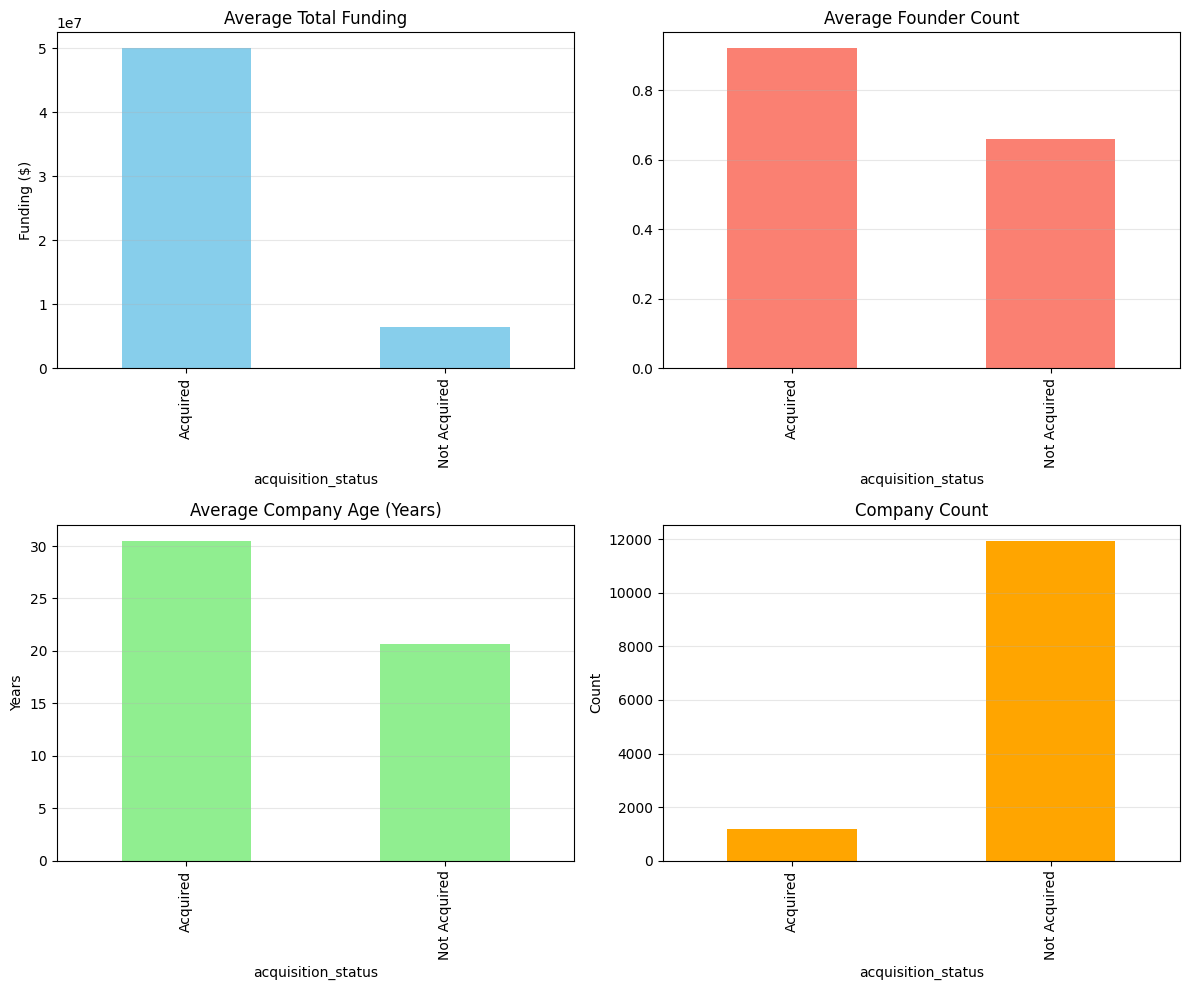

In [136]:
import matplotlib.pyplot as plt

# Ensure acquisition_status is the x-axis
x_col = "acquisition_status"

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Average Total Funding
df_comparison.plot(
    x=x_col, y="avg_total_funding",
    kind="bar", ax=axes[0,0], legend=False, color="skyblue"
)
axes[0,0].set_title("Average Total Funding")
axes[0,0].set_ylabel("Funding ($)")
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Average Founder Count
df_comparison.plot(
    x=x_col, y="avg_founder_count",
    kind="bar", ax=axes[0,1], legend=False, color="salmon"
)
axes[0,1].set_title("Average Founder Count")
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Average Company Age
df_comparison.plot(
    x=x_col, y="avg_company_age_years",
    kind="bar", ax=axes[1,0], legend=False, color="lightgreen"
)
axes[1,0].set_title("Average Company Age (Years)")
axes[1,0].set_ylabel("Years")
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Company Count
df_comparison.plot(
    x=x_col, y="company_count",
    kind="bar", ax=axes[1,1], legend=False, color="orange"
)
axes[1,1].set_title("Company Count")
axes[1,1].set_ylabel("Count")
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()




#Interpretation

Acquired companies look very different from non-acquired ones. They tend to raise far more funding on average often several times higher showing that strong investor backing is a major predictor of acquisition success. They also have slightly larger founding teams and are typically older, meaning they’ve had more time to mature, build traction, and become attractive targets. Non-acquired firms, while far more common, show much lower funding levels and younger company ages. Overall, acquisitions appear to favor companies with deeper capital support, more established leadership structures, and longer operating histories.

# **Executive Summary for Horizon Ventures Investment Committee**

This report summarizes key insights derived from an analysis of 18,801 companies from the Crunchbase dataset, focusing on funding dynamics, category level patterns, and acquisition outcomes. The goal is to provide evidence based guidance to support Horizon Ventures investment decisions.


###Key Insights

## **Insight 1: Venture Funding Exhibits Strong Winner-Takes-Most Dynamics**

Across nearly all categories, funding is heavily concentrated among a small number of companies. The top firms within a category often receive five to ten times more capital than the median firm. This pattern is particularly pronounced in software, web, and enterprise technology, which also show the highest cumulative funding growth over time. These findings indicate that early leaders tend to attract disproportionate investor attention. For Horizon Ventures, this suggests that company level positioning especially signs of early leadership is more predictive of long term performance than broad sector selection alone.



## **Insight 2: Individual Funding Rounds Vary Dramatically from Annual Averages**

Funding rounds within a given year show wide dispersion, with some companies raising several times more than the annual average while others fall far below it. These outliers signal that investors tend to concentrate capital into companies they believe have exceptional growth potential. This reinforces the need to identify companies that consistently raise above average rounds, as they are more likely to be viewed as category frontrunners. Monitoring these patterns can help identify emerging leaders earlier in their trajectory.


## **Insight 3: Acquired Companies Show Distinct Funding and Maturity Characteristics**

Our comparison of 4,412 acquired companies with the remaining non-acquired firms reveals clear differences. Acquired firms have significantly higher total funding often several multiples above their non-acquired peers and tend to be older and more structurally established. This indicates that successful exits generally require both sufficient capital and enough time for a company to mature into an attractive acquisition target. For investors, this underscores the importance of supporting follow on funding and maintaining realistic timelines for exits.

## **Insight 4: Acquisition Likelihood Varies Sharply Across Categories**

Acquisition rates differ widely across industry categories. Some sectors exceed a 25% acquisition rate, while others fall below 10%, despite having similar funding totals. This variation suggests that certain categories are inherently more attractive to strategic buyers, likely due to market consolidation opportunities or integration value. Understanding which categories historically generate higher acquisition activity can help Horizon Ventures assess exit potential more accurately when evaluating new opportunities.


## **Insight 5: Acquisition Outcomes Align with Specific Funding Ranges**

The analysis of funding distribution reveals that companies within certain funding ranges have noticeably higher acquisition rates. Firms with too little funding often lack the resources required to reach scale, while excessively funded companies may become too expensive for acquisition. This indicates the presence of a “sweet spot” in funding—generally within the moderate range—where acquisition likelihood is highest. This insight can help investors determine optimal check sizes and follow-on strategies to maximize future exit potential.


### Investment Recommendation

Based on the results of this analysis, Horizon Ventures should prioritize investments in **companies that display early category leadership within sectors that show historically strong acquisition activity**.

### Recommended Target Profile:

* Operates within a category with acquisition rates above the dataset average
* Has raised funding rounds 50% or more above its year’s average
* Shows signals of emerging leadership relative to competitors
* Has a founding team size in the range commonly associated with successful acquisitions
* Is in the 3–7 year age range, which aligns with the observed acquisition timing window
* Has total funding within the moderate “acquisition sweet spot” rather than the extremes

### Logic:

This recommendation is supported by three major findings from the analysis:

1. Category leaders attract disproportionate funding and follow a steeper growth trajectory.
2. Higher funding depth and maturity correlate with higher acquisition rates.
3. Categories with strong historical acquisition activity offer more predictable exit opportunities.

By focusing on companies that meet these criteria, Horizon Ventures can improve the likelihood of backing firms that become acquisition targets while avoiding overexposure to sectors or profiles with weaker exit potential.


###Data Limitations

This analysis is based on historical Crunchbase data and may not fully capture emerging trends, recent market shifts, or qualitative factors such as product-market fit or leadership quality. Acquisition reporting may also be incomplete. Therefore, while the findings provide useful directional guidance, they should be combined with ongoing market monitoring and qualitative due diligence when making final investment decisions.


##Conclusion

The venture capital landscape exhibits strong indicators of predictable funding and acquisition patterns. Companies that secure above-average funding rounds, demonstrate early market leadership, and operate in historically acquisition-active categories show the most promising exit potential. By prioritizing such companies and supporting them through the critical 3–7 year maturation period, Horizon Ventures can better position its portfolio for strong long-term outcomes.

